In [1]:
from pathlib import Path
import sys
import os

# Add parent directory to Python path
project_root = Path("/home/nbyrnes/code/random-matrix/")  # <-- adjust this
sys.path.insert(0, str(project_root))

import pickle
import time
import warnings
import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse
import shapely
import tqdm
import quadpy
import warnings
from random_matrix.amplitude_matrix import (
    isotropic_sphere,
    scattering_geometry,
)
from random_matrix.input_statistics import density_function, density_integrals
from random_matrix.input_statistics.density_function import (
    DeltaDensityFactor,
    DensityFunction,
    DensityFunctionTerm,
    RegularDensityFactor,
)
from random_matrix.input_statistics.index_finder import IndexFinder
from random_matrix.input_statistics.input_statistics_manager import (
    InputStatisticsManager,
)
from random_matrix.input_statistics.integration_task import (
    IntegrationTaskPreparer,
    IntegrationTaskConfig,
)
from random_matrix.input_statistics.medium_parameters import MediumParameters
from random_matrix.input_statistics.medium_statistics import (
    MediumStatistics,
    ParticleStatistics,
)
from random_matrix.modes import mode_grid, mode_grid_factory
from random_matrix.utils import (
    array_utils,
    function_utils,
    geometry_utils,
    integration_utils,
    matrix_utils,
    special_functions,
)
from random_matrix.scattering_matrix import sampler

In [2]:
# -----------------------------------------------------------------------------
# Simulation parameters
# -----------------------------------------------------------------------------

wavelength = 550e-9
slab_thickness = 1.8992695221776513e-06
number_density = 5.921762640653617e17
medium_parameters = MediumParameters(
    wavelength=wavelength,
    number_density=number_density,
    slab_thickness=slab_thickness,
)
term = DensityFunctionTerm.from_delta({"x": 2.0, "m": 1.2})

# 2D version
particle_statistics_2d = ParticleStatistics(
    term,
    isotropic_sphere.get_A,
    isotropic_sphere.get_A_product,
    isotropic_sphere.get_A_product_conj,
)
medium_statistics_2d = MediumStatistics([particle_statistics_2d])

In [3]:
my_grid = mode_grid_factory.from_tiling(
    tiling_type="rectangles",
    side_length=(0.3, 0.3),
    r_lim=1.2,
    grid_wave_type="propagating",
    rotation_angle=0.0,
    translation_vector=np.array([0.0, 0.0]),
)
my_grid.plot()
print(my_grid.num_propagating)

45


In [4]:
use_np_config = IntegrationTaskConfig(use_gpu=False)

num_modes = my_grid.num_propagating
print(f"Starting num_modes = {num_modes}")
# 2D
simulation_name = f"debugging"
input_statistics_manager_2d = InputStatisticsManager(
    simulation_name,
    medium_parameters,
    medium_statistics_2d,
    my_grid,
    supplied_indices=None,
    use_dirac_density=False,
    integration_method="midpoint",
    covariance_cubature_scheme=None,
    integration_task_config=use_np_config,
)
mean_S, chol, cov = input_statistics_manager_2d.get_statistics()

Starting num_modes = 45


/tmp/ipykernel_7260/1889068693.py:7: UserWarning: No parent_data_dir provided. Defaulting to current working directory: /home/nbyrnes/code/random-matrix/paper_data/data.
  input_statistics_manager_2d = InputStatisticsManager(


[09/20 16:17:53] Get mean matrix
[09/20 16:17:53] Done
[09/20 16:17:53] Get covariance matrix
[09/20 16:17:56] Done
[09/20 16:17:56] 
[09/20 16:17:56] Done
POWER USED FOR CHOL: 10^-17


In [5]:
np.any(np.isnan(cov.data))

False

### Check reciprocity

In [6]:
my_grid.num_propagating

45

In [7]:
S = sampler.S_sampler(mean_S, chol, 1)[0]

In [8]:
print(matrix_utils.get_sub_block(S, "r", (12,-2)))
print(matrix_utils.get_sub_block(S, "r", (2,-12)))

[[-8.77292469e-04-1.70354741e-04j -3.65856060e-04-3.97075151e-04j]
 [-3.05832349e-05+3.19204963e-04j -2.36412938e-04-7.60984045e-05j]]
[[-8.77296013e-04-1.70353773e-04j  3.05864893e-05-3.19209019e-04j]
 [ 3.65859880e-04+3.97078181e-04j -2.36408833e-04-7.61006439e-05j]]


In [9]:
cov.shape[0]

32400

In [10]:
np.set_printoptions(precision=2)
R = np.array(
    [
        [1.0, 0.0, 0.0, 0.0],
        [0.0, 0.0, -1.0, 0.0],
        [0.0, -1.0, 0.0, 0.0],
        [0.0, 0.0, 0.0, 1.0],
    ]
)


(-22, -22)
6.735594871772985e-21
0.0
0.0
(-22, -21)
1.3136497429729963e-21
0.0
0.0
(-22, -20)
3.8815019299994893e-20
0.0
0.0
(-22, -19)
8.305821322332904e-21
0.0
0.0
(-22, -18)
5.837592015625358e-21
0.0
0.0
(-22, -17)
2.3040875053032532e-21
0.0
0.0
(-22, -16)
6.474282996140661e-22
0.0
0.0
(-22, -15)
4.365507887384641e-22
0.0
0.0
(-22, -14)
1.6905243846154906e-20
0.0
0.0
(-22, -13)
5.807599684121121e-20
3.38854535408301e-21
6.776263578034403e-21
(-22, -12)
3.222155915681168e-21
0.0
0.0
(-22, -11)
3.501967847181511e-20
0.0
0.0
(-22, -10)
2.113155480647971e-22
0.0
0.0
(-22, -9)
7.444000727608022e-21
0.0
0.0
(-22, -8)
1.690524383684249e-21
0.0
0.0
(-22, -7)
3.0759842871832605e-20
0.0
0.0
(-22, -6)
1.3552527156068805e-20
1.3552527156068805e-20
2.371692252312041e-20
(-22, -5)
1.4653222681560763e-20
0.0
0.0
(-22, -4)
6.481651990820984e-20
1.6940658945086007e-21
3.3881317890172014e-21
(-22, -3)
1.7251119689982968e-20
0.0
0.0
(-22, -2)
0.0
0.0
0.0
(-22, -1)
1.457892873991092e-20
3.3881317890172

Text(0.5, 1.0, '2.1728467174382843e-18')

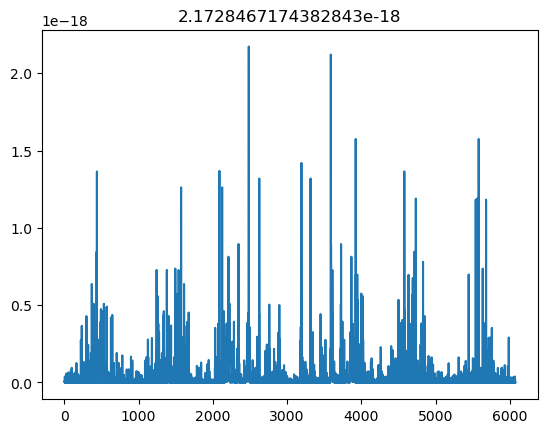

In [11]:
i = 12
j = -2
data = []
for i in my_grid.propagating_indices:
    for j  in my_grid.propagating_indices:

        print((i,j))
        c1 = matrix_utils.get_cov_sub_block(cov, "r,r", (i, j, i, j))
        c2 = matrix_utils.get_cov_sub_block(cov, "r,r", (i, j, -j, -i))
        c3 = matrix_utils.get_cov_sub_block(cov, "r,r", (-j, -i, i, j))
        c4 = matrix_utils.get_cov_sub_block(cov, "r,r", (-j, -i, -j, -i))

        # print(np.max(np.abs(c1)))
        # print(np.max(np.abs(c2)))
        # print(np.max(np.abs(c3)))
        # print(np.max(np.abs(c4)))
        # print("----------")
        new_data1 = np.max(np.abs(c1 - c2 @ R))
        new_data2 = np.max(np.abs(c1 - R @ c3))
        new_data3 = np.max(np.abs(c1 - R @ c4 @ R))
        data.append(new_data1)
        data.append(new_data2)
        data.append(new_data3)
        print(np.max(np.abs(c1 - c2 @ R)))
        print(np.max(np.abs(c1 - R @ c3)))
        print(np.max(np.abs(c1 - R @ c4 @ R)))
        # print("---")
        # print(np.max(np.abs(c1 - R @ c2)))
        # print(np.max(np.abs(c1 - c3 @ R)))
        # print(np.max(np.abs(c1 - c4 @ R)))

fig, ax = plt.subplots()
ax.plot(range(len(data)), data)
ax.set_title(np.max(data))
# s1 = matrix_utils.get_sub_block(S, "r", (12, -2))
# s2 = matrix_utils.get_sub_block(S, "r", (2, -12))
# print(s1)
# print(s2)
# print(np.max(np.abs(s1)))
# print(np.max(np.abs(s2)))
# print(np.max(np.abs(s1 - matrix_utils.r_sym(s2))))

In [12]:
i = -22
j = -19
c1 = matrix_utils.get_cov_sub_block(cov, "r,r", (i, j, i, j))
c2 = matrix_utils.get_cov_sub_block(cov, "r,r", (i, j, -j, -i))
c3 = matrix_utils.get_cov_sub_block(cov, "r,r", (-j, -i, i, j))
c4 = matrix_utils.get_cov_sub_block(cov, "r,r", (-j, -i, -j, -i))
print(np.max(np.abs(c1)))
print(np.max(np.abs(c2)))
print(np.max(np.abs(c3)))
print(np.max(np.abs(c4)))
print("----------")
print(np.max(np.abs(c1 - c2 @ R)))
print(np.max(np.abs(c1 - R @ c3)))
print(np.max(np.abs(c1 - R @ c4 @ R)))
print("---")
print(np.max(np.abs(c1 - R @ c2)))
print(np.max(np.abs(c1 - c3 @ R)))
print(np.max(np.abs(c1 - c4 @ R)))

s1 = matrix_utils.get_sub_block(S, "r", (12, -2))
s2 = matrix_utils.get_sub_block(S, "r", (2, -12))
print(s1)
print(s2)
print(np.max(np.abs(s1)))
print(np.max(np.abs(s2)))
print(np.max(np.abs(s1 - matrix_utils.r_sym(s2))))

5.486593451464377e-06
5.486593451464377e-06
5.486593451464377e-06
5.486593451464377e-06
----------
8.305821322332904e-21
0.0
0.0
---
2.169956973420373e-06
2.1699569734203728e-06
2.169956973420365e-06
[[-8.77e-04-1.70e-04j -3.66e-04-3.97e-04j]
 [-3.06e-05+3.19e-04j -2.36e-04-7.61e-05j]]
[[-8.77e-04-1.70e-04j  3.06e-05-3.19e-04j]
 [ 3.66e-04+3.97e-04j -2.36e-04-7.61e-05j]]
0.0008936793685889408
0.000893682663447905
5.2003114524521424e-09


(-22, -22)
1.1044061139633504e-19
0.0
0.0
(-22, -21)
1.0363185292925636e-19
0.0
0.0
(-22, -20)
1.6612214360366398e-19
0.0
0.0
(-22, -19)
1.493063765185181e-19
0.0
0.0
(-22, -18)
1.8976562895043006e-19
0.0
0.0
(-22, -17)
4.0661601367255566e-19
0.0
0.0
(-22, -16)
1.9824442075785378e-19
0.0
0.0
(-22, -15)
8.206624766831407e-20
0.0
0.0
(-22, -14)
2.168404344971009e-19
0.0
0.0
(-22, -13)
2.1813359770301135e-19
5.421672566532815e-20
1.0842021724855044e-19
(-22, -12)
7.461473580173355e-21
0.0
0.0
(-22, -11)
5.02764538249442e-19
0.0
0.0
(-22, -10)
0.0
0.0
0.0
(-22, -9)
4.387643441748833e-19
0.0
0.0
(-22, -8)
1.2418857838881997e-19
0.0
0.0
(-22, -7)
3.525122774298533e-19
0.0
0.0
(-22, -6)
4.0657581468206416e-20
4.0657581468206416e-20
9.486769009248164e-20
(-22, -5)
9.529361822662162e-20
0.0
0.0
(-22, -4)
7.932575477985505e-19
2.710505431213761e-20
5.421010862427522e-20
(-22, -3)
1.4569028250270897e-19
0.0
0.0
(-22, -2)
0.0
0.0
0.0
(-22, -1)
4.785736151986797e-20
1.355418141633204e-20
2.71050543

Text(0.5, 1.0, '1.6101624839461807e-17')

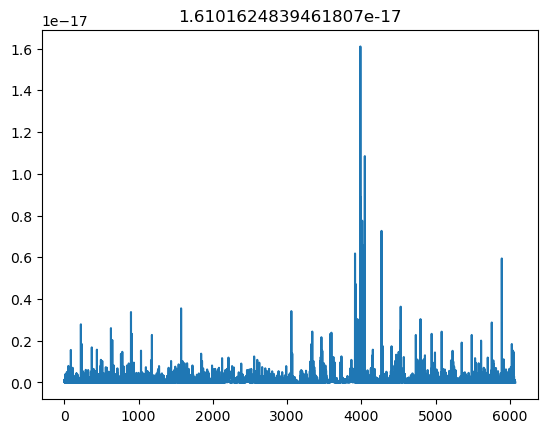

In [13]:
i = 12
j = -2
data = []
for i in my_grid.propagating_indices:
    for j  in my_grid.propagating_indices:

        print((i,j))
        c1 = matrix_utils.get_cov_sub_block(cov, "t,t", (i, j, i, j))
        c2 = matrix_utils.get_cov_sub_block(cov, "t,t2", (i, j, -j, -i))
        c3 = matrix_utils.get_cov_sub_block(cov, "t2,t", (-j, -i, i, j))
        c4 = matrix_utils.get_cov_sub_block(cov, "t2,t2", (-j, -i, -j, -i))

        # print(np.max(np.abs(c1)))
        # print(np.max(np.abs(c2)))
        # print(np.max(np.abs(c3)))
        # print(np.max(np.abs(c4)))
        # print("----------")
        new_data1 = np.max(np.abs(c1 - c2 @ R))
        new_data2 = np.max(np.abs(c1 - R @ c3))
        new_data3 = np.max(np.abs(c1 - R @ c4 @ R))
        data.append(new_data1)
        data.append(new_data2)
        data.append(new_data3)
        print(np.max(np.abs(c1 - c2 @ R)))
        print(np.max(np.abs(c1 - R @ c3)))
        print(np.max(np.abs(c1 - R @ c4 @ R)))
        # print("---")
        # print(np.max(np.abs(c1 - R @ c2)))
        # print(np.max(np.abs(c1 - c3 @ R)))
        # print(np.max(np.abs(c1 - c4 @ R)))

fig, ax = plt.subplots()
ax.plot(range(len(data)), data)
ax.set_title(np.max(data))
# s1 = matrix_utils.get_sub_block(S, "r", (12, -2))
# s2 = matrix_utils.get_sub_block(S, "r", (2, -12))
# print(s1)
# print(s2)
# print(np.max(np.abs(s1)))
# print(np.max(np.abs(s2)))
# print(np.max(np.abs(s1 - matrix_utils.r_sym(s2))))

In [14]:

print(
    matrix_utils.get_cov_sub_block_indices(
        "t,t", (-24, -25, -25, -25), True, my_grid.num_propagating
    )
)
print(
    matrix_utils.get_cov_sub_block_indices(
        "t2,t", (25, 24, -25, -25), True, my_grid.num_propagating
    )
)
print(
    matrix_utils.get_cov_sub_block_indices(
        "t,t2", (-24, -25, 25, 25), True, my_grid.num_propagating
    )
)
print(
    matrix_utils.get_cov_sub_block_indices(
        "t2,t2", (25, 24, 25, 25), True, my_grid.num_propagating
    )
)

print(np.max(np.abs(cov-np.conj(cov).T)))

(slice(7552, 7556, None), slice(7548, 7552, None))
(slice(24668, 24672, None), slice(7548, 7552, None))
(slice(7552, 7556, None), slice(24848, 24852, None))
(slice(24668, 24672, None), slice(24848, 24852, None))
1.6101624839461807e-17


In [15]:
i = 12
j = -2

c1 = matrix_utils.get_cov_sub_block(cov, "t,t", (i, j, i, j))
c2 = matrix_utils.get_cov_sub_block(cov, "t,t2", (i, j, -j, -i))
c3 = matrix_utils.get_cov_sub_block(cov, "t2,t", (-j, -i, i, j))
c4 = matrix_utils.get_cov_sub_block(cov, "t2,t2", (-j, -i, -j, -i))

print(np.max(np.abs(c1)))
print(np.max(np.abs(c2)))
print(np.max(np.abs(c3)))
print(np.max(np.abs(c4)))
print("----------")
print(np.max(np.abs(c1 - c2 @ R)))
print(np.max(np.abs(c1 - R @ c3)))
print(np.max(np.abs(c1 - R @ c4 @ R)))
print("---")
print(np.max(np.abs(c1 - R @ c2)))
print(np.max(np.abs(c1 - c3 @ R)))
print(np.max(np.abs(c1 - c4 @ R)))

s1 = matrix_utils.get_sub_block(S, "t", (12, -2))
s2 = matrix_utils.get_sub_block(S, "t2", (2, -12))
print(s1)
print(s2)
print(np.max(np.abs(s1)))
print(np.max(np.abs(s2)))
print(np.max(np.abs(s1 - matrix_utils.r_sym(s2))))

4.1203088447270095e-05
4.120308844727011e-05
4.120308844727011e-05
4.120308844727012e-05
----------
1.4025281967740643e-20
1.3552527156068805e-20
2.710505431213761e-20
---
5.799934190905668e-06
5.799934190905671e-06
5.1814795590739616e-06
[[-1.63e-03+5.16e-04j  9.82e-04-4.85e-04j]
 [-8.57e-04+5.03e-05j -1.25e-05-3.07e-04j]]
[[-1.63e-03+5.16e-04j  8.57e-04-5.03e-05j]
 [-9.82e-04+4.85e-04j -1.25e-05-3.07e-04j]]
0.0017095846057968366
0.001709586554717402
9.17835791711641e-09


In [16]:
indices = (-10, 5)
rec_indices = (-5, 10)

[[ 9.96e-01+6.29e-02j -1.60e-05+1.33e-05j]
 [-4.37e-05+1.14e-05j  9.96e-01+6.27e-02j]]

[[9.96e-01+6.29e-02j 4.37e-05-1.14e-05j]
 [1.60e-05-1.33e-05j 9.96e-01+6.27e-02j]]
---
[[-0.01-3.34e-03j  0.  +9.52e-05j]
 [ 0.  +4.81e-05j -0.01-3.31e-03j]]

[[-0.01-3.34e-03j -0.  -4.81e-05j]
 [-0.  -9.52e-05j -0.01-3.31e-03j]]
---
[[ 1.56e-02+4.92e-03j -1.77e-04-1.73e-04j]
 [-4.50e-05+1.55e-05j  1.98e-02+6.23e-03j]]

[[1.56e-02+4.92e-03j 4.50e-05-1.55e-05j]
 [1.77e-04+1.73e-04j 1.98e-02+6.23e-03j]]
---
[[ 0.+0.j    0.+0.j  ]
 [-0.-0.j    0.+0.01j]]

[[ 0.+0.j    0.+0.j  ]
 [-0.-0.j    0.+0.01j]]
---
[[ 0.-0.j  0.-0.j]
 [-0.+0.j  0.-0.j]]

[[ 0.-0.j  0.-0.j]
 [-0.+0.j  0.-0.j]]
---
[[ 0.+0.j  0.+0.j]
 [-0.-0.j  0.+0.j]]

[[ 0.+0.j  0.+0.j]
 [-0.-0.j  0.+0.j]]
---
[[ 0.  +5.20e-04j -0.01-6.20e-03j]
 [ 0.01+6.10e-03j  0.  +9.48e-05j]]

[[ 0.  +5.20e-04j -0.01-6.10e-03j]
 [ 0.01+6.20e-03j  0.  +9.48e-05j]]
---
[[ 0.01-0.j -0.01+0.j]
 [ 0.01-0.j  0.01-0.j]]

[[ 0.01-0.j -0.01+0.j]
 [ 0.01-0.j  0.01-0.

Text(0.5, 1.0, 't')

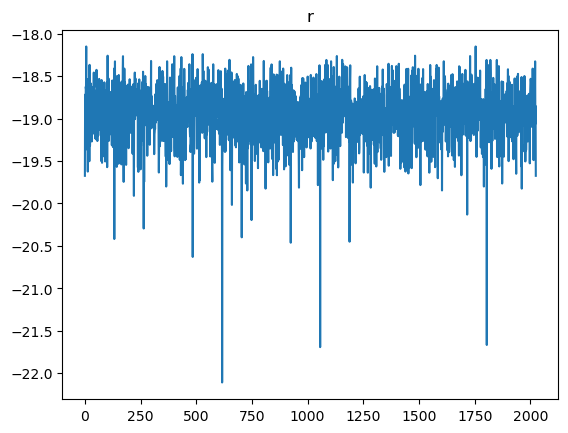

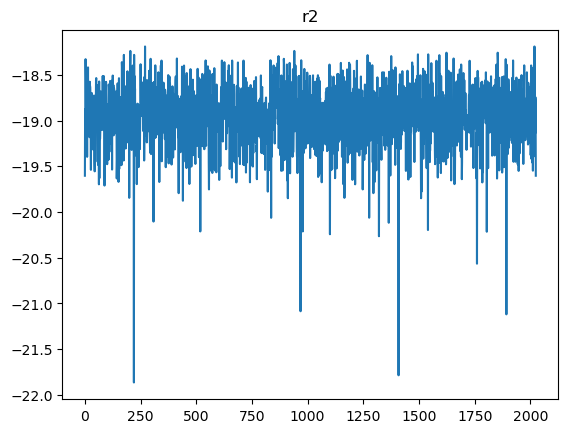

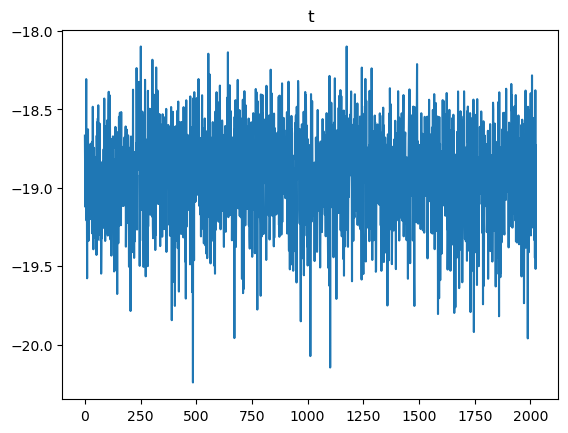

In [17]:
S = sampler.S_sampler(mean_S, chol, 1)[0]
half_index = int(len(S) // 2)

r = S[:half_index, :half_index]
t = S[half_index:, :half_index]
t2 = S[:half_index, half_index:]
r2 = S[:half_index, :half_index]

data_r = []
data_t = []
data_r2 = []

for i in my_grid.propagating_indices:
    for j in my_grid.propagating_indices:
        indices = (i, j)
        rec_indices = (-j, -i)

        # r
        block_indices = matrix_utils.get_sub_block_indices(
            "r", indices, True, my_grid.num_propagating
        )
        rec_block_indices = matrix_utils.get_sub_block_indices(
            "r", rec_indices, True, my_grid.num_propagating
        )
        block = S[block_indices]
        rec_block = S[rec_block_indices]
        data_r.append(
            np.log(np.max(np.abs(block - matrix_utils.r_sym(rec_block))))
        )

        # r2
        block_indices = matrix_utils.get_sub_block_indices(
            "r2", indices, True, my_grid.num_propagating
        )
        rec_block_indices = matrix_utils.get_sub_block_indices(
            "r2", rec_indices, True, my_grid.num_propagating
        )
        block = S[block_indices]
        rec_block = S[rec_block_indices]
        data_r2.append(
            np.log(np.max(np.abs(block - matrix_utils.r_sym(rec_block))))
        )

        # t
        block_indices = matrix_utils.get_sub_block_indices(
            "t", indices, True, my_grid.num_propagating
        )
        rec_block_indices = matrix_utils.get_sub_block_indices(
            "t2", rec_indices, True, my_grid.num_propagating
        )
        block = S[block_indices]
        rec_block = S[rec_block_indices]
        data_t.append(
            np.log(np.max(np.abs(block - matrix_utils.r_sym(rec_block))))
        )

        print(block)
        print()
        print(rec_block)
        print("---")


fig, ax = plt.subplots()
ax.plot(range(len(data_r)), data_r)
ax.set_title("r")

fig, ax = plt.subplots()
ax.plot(range(len(data_r2)), data_r2)
ax.set_title("r2")

fig, ax = plt.subplots()
ax.plot(range(len(data_t)), data_t)
ax.set_title("t")

In [18]:
indices = (4, -12)
rec_indices = (12, -4)

block_one_auto = (*indices, *indices)
block_two_auto = (*rec_indices, *rec_indices)
block_one_two = (*indices, *rec_indices)
block_two_one = (*rec_indices, *indices)

# r,r
block_one_cov = cov[
    matrix_utils.get_cov_sub_block_indices(
        "r,r", block_one_auto, True, my_grid.num_propagating
    )
]
block_two_cov = cov[
    matrix_utils.get_cov_sub_block_indices(
        "r,r", block_two_auto, True, my_grid.num_propagating
    )
]
block_one_two_cov = cov[
    matrix_utils.get_cov_sub_block_indices(
        "r,r", block_one_two, True, my_grid.num_propagating
    )
]
block_two_one_cov = cov[
    matrix_utils.get_cov_sub_block_indices(
        "r,r", block_two_one, True, my_grid.num_propagating
    )
]



np.set_printoptions(precision=3)
print(block_one_cov.todense())
print(block_two_cov.todense())
print(block_one_two_cov.todense())
print(block_two_one_cov.todense())



[[ 2.358e-06-1.039e-20j -2.372e-07+1.241e-07j -6.693e-07-3.383e-08j
  -1.348e-06+3.692e-07j]
 [-2.372e-07-1.241e-07j  3.039e-08-4.183e-22j  6.553e-08+3.863e-08j
   1.550e-07+3.383e-08j]
 [-6.693e-07+3.383e-08j  6.553e-08-3.863e-08j  1.905e-07-4.890e-22j
   3.774e-07-1.241e-07j]
 [-1.348e-06-3.692e-07j  1.550e-07-3.383e-08j  3.774e-07+1.241e-07j
   8.285e-07-3.847e-21j]]
[[ 2.358e-06-1.039e-20j  6.693e-07+3.383e-08j  2.372e-07-1.241e-07j
  -1.348e-06+3.692e-07j]
 [ 6.693e-07-3.383e-08j  1.905e-07-4.890e-22j  6.553e-08-3.863e-08j
  -3.774e-07+1.241e-07j]
 [ 2.372e-07+1.241e-07j  6.553e-08+3.863e-08j  3.039e-08-4.183e-22j
  -1.550e-07-3.383e-08j]
 [-1.348e-06-3.692e-07j -3.774e-07-1.241e-07j -1.550e-07+3.383e-08j
   8.285e-07-3.847e-21j]]
[[ 2.358e-06+1.039e-20j  6.693e-07+3.383e-08j  2.372e-07-1.241e-07j
  -1.348e-06+3.692e-07j]
 [-2.372e-07-1.241e-07j -6.553e-08-3.863e-08j -3.039e-08-4.183e-22j
   1.550e-07+3.383e-08j]
 [-6.693e-07+3.383e-08j -1.905e-07-4.890e-22j -6.553e-08+3.863e-08j


In [19]:
S = sampler.S_sampler(mean_S, chol, 1)[0]
block_one_indices = matrix_utils.get_sub_block_indices(
    "r", indices, True, my_grid.num_propagating
)
block_two_indices = matrix_utils.get_sub_block_indices(
    "r", rec_indices, True, my_grid.num_propagating
)

block_one = S[block_one_indices]
block_two = S[block_two_indices]
r = S[0:90, 0:90]
print(np.max(np.abs(r - matrix_utils.r_sym(r))))



print(block_one)
print(block_two)
print(np.max(np.abs(block_one - matrix_utils.r_sym(block_two))))

0.04149771207464188
[[-0.001+2.531e-04j  0.   +1.589e-04j]
 [ 0.   -2.421e-04j  0.001-3.477e-05j]]
[[-0.001+2.531e-04j -0.   +2.421e-04j]
 [-0.   -1.589e-04j  0.001-3.477e-05j]]
6.437789297595878e-09


In [20]:
r = matrix_utils.get_block(S, "r")
t = matrix_utils.get_block(S, "t")
t2 = matrix_utils.get_block(S, "t2")
r2 = matrix_utils.get_block(S, "r2")

print(matrix_utils.get_sub_block(S, "r", (2, -3)))
print(matrix_utils.get_sub_block(S, "r", (3, -2)))

print(matrix_utils.get_sub_block(S, "t", (2, -3)))
print(matrix_utils.get_sub_block(S, "t2", (3, -2)))

[[ 0.001-0.002j -0.   +0.j   ]
 [-0.   +0.j    -0.001+0.002j]]
[[ 0.001-0.002j  0.   -0.j   ]
 [ 0.   -0.j    -0.001+0.002j]]
[[ 0.001+0.j     0.001+0.j   ]
 [-0.001-0.001j -0.002-0.001j]]
[[ 0.001+0.j     0.001+0.001j]
 [-0.001-0.j    -0.002-0.001j]]


[[1.000e+00 3.614e-16 2.501e-16 ... 2.642e-16 2.973e-16 1.388e-16]
 [3.614e-16 1.000e+00 1.221e-16 ... 2.995e-16 6.870e-17 1.303e-16]
 [2.501e-16 1.221e-16 1.000e+00 ... 4.274e-16 1.197e-16 2.819e-16]
 ...
 [2.642e-16 2.995e-16 4.274e-16 ... 1.000e+00 5.680e-16 9.589e-17]
 [2.973e-16 6.870e-17 1.197e-16 ... 5.680e-16 1.000e+00 1.603e-16]
 [1.388e-16 1.303e-16 2.819e-16 ... 9.589e-17 1.603e-16 1.000e+00]]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


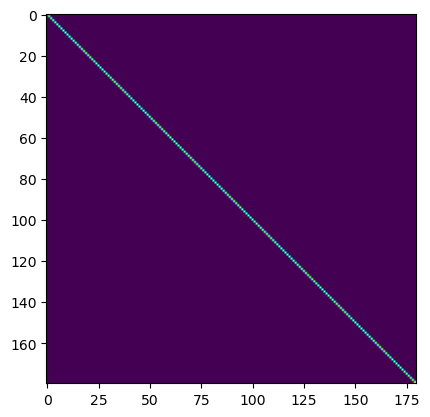

In [21]:
prod = np.abs(np.conj(S.T) @ S)
print(prod)
fig, ax = plt.subplots()
ax.imshow(np.abs(prod))


u, s, vh = np.linalg.svd(S)
print(s)

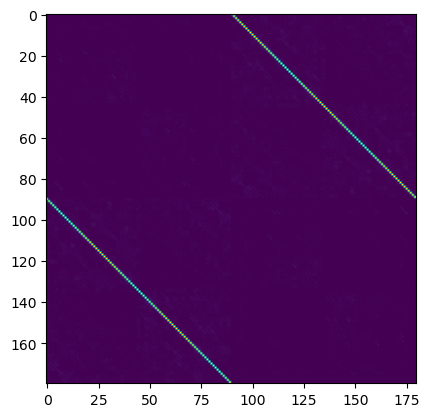

In [22]:
plt.imshow(np.abs(S))

In [23]:
S = sampler.S_sampler(mean_S, chol, 10)

u,s,vh = np.linalg.svd(S)
print(u.shape)
print(s.shape)
print(vh.shape)
print((u@vh).shape)

(10, 180, 180)
(10, 180)
(10, 180, 180)
(10, 180, 180)


In [24]:
S = sampler.S_sampler(mean_S, chol, 100, symmetrize=False)
S_sym = matrix_utils.get_closest_unitary_approximation(S)

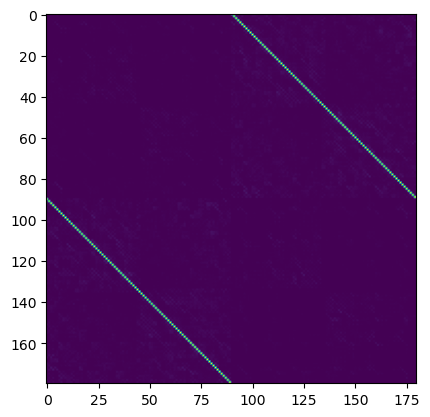

In [25]:
plt.imshow(np.abs(S[0]))

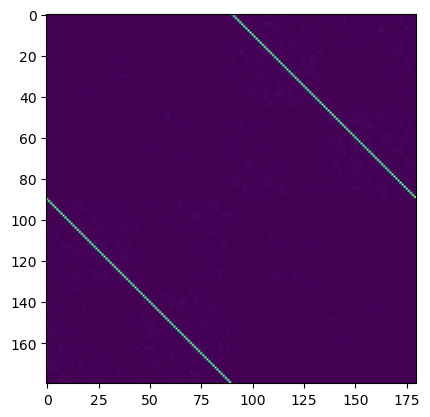

In [26]:
plt.imshow(np.abs(S_sym[0]))

In [27]:
np.set_printoptions(precision=8)
i = 4
j = 12

print(matrix_utils.get_sub_block(S_sym[0], "t", (i, j)))
print(matrix_utils.get_sub_block(S_sym[0], "t2", (-j, -i)))

print(
    matrix_utils.get_sub_block(S[0], "t", (i, j))
    - matrix_utils.r_sym(matrix_utils.get_sub_block(S[0], "t2", (-j, -i)))
)

[[-0.00665234+0.00804147j  0.00116304-0.00174425j]
 [-0.00166443+0.00231372j -0.00610826+0.00706691j]]
[[-0.00665234+0.00804147j  0.00166443-0.00231372j]
 [-0.00116304+0.00174425j -0.00610826+0.00706691j]]
[[-1.44795719e-09+9.74913453e-10j -1.79818441e-09-2.50639137e-09j]
 [-7.85940595e-09-4.22444933e-09j  6.53259818e-10-1.83510711e-10j]]


In [28]:
# my_S = S[0]
# w = matrix_utils.get_S_reciprocity_matrix(len(my_S))
# for my_S in S:
#     print(np.max(np.abs(my_S - w @ my_S.T @ w
# )))
print(S.shape)
print(matrix_utils.get_block(S, "r").shape)
print(matrix_utils.get_block(S, "r")[2].shape)
print(matrix_utils.get_block(S[2], "r").shape)

print(matrix_utils.get_block(S, "r")[2] - matrix_utils.get_block(S[2], "r"))

(100, 180, 180)
(100, 90, 90)
(90, 90)
(90, 90)
[[0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 ...
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]]


In [29]:
t2 = matrix_utils.get_block(S, "t2")
print(t2.shape)

t2_inv = np.linalg.inv(t2)
print(t2_inv[17] - np.linalg.inv(t2[17]))

(100, 90, 90)
[[0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 ...
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]]


In [30]:
r = matrix_utils.get_block(S, "r")
r2 = matrix_utils.get_block(S, "r2")
t = matrix_utils.get_block(S, "t")
t2 = matrix_utils.get_block(S, "t2")

t2_inv = np.linalg.inv(t2)
a = t - r2 @ t2_inv @ r
b = r2 @ t2_inv
c = -t2_inv @ r
d = t2_inv

top = np.concatenate((a, b), axis=2)  # (M, 2, 4)
bottom = np.concatenate((c, d), axis=2)  # (M, 2, 4)
M = np.concatenate((top, bottom), axis=1)  # (M, 4, 4)


In [31]:
r = matrix_utils.get_block(S[17], "r")
r2 = matrix_utils.get_block(S[17], "r2")
t = matrix_utils.get_block(S[17], "t")
t2 = matrix_utils.get_block(S[17], "t2")

t2_inv = np.linalg.inv(t2)
a = t - r2 @ t2_inv @ r
b = r2 @ t2_inv
c = -t2_inv @ r
d = t2_inv

top = np.concatenate((a, b), axis=1)  # (M, 2, 4)
bottom = np.concatenate((c, d), axis=1)  # (M, 2, 4)
M2 = np.concatenate((top, bottom), axis=0)  # (M, 4, 4)


In [32]:
print(M[17] - M2)

[[0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 ...
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]]


In [33]:
M.shape

(100, 180, 180)

In [41]:
M = matrix_utils.get_M_from_S(S_sym)
S_back = matrix_utils.get_S_from_M(M)
print(np.max(np.abs(S_back - S_sym)))


1.0053497077208614e-15


In [35]:
assert False

AssertionError: 

In [ ]:
mean_S_path = input_statistics_manager_2d.simulation_path / "mean_S.npy"
chol_path = input_statistics_manager_2d.simulation_path / "chol.npz"

np.save(mean_S_path, mean_S)
scipy.sparse.save_npz(chol_path, chol)


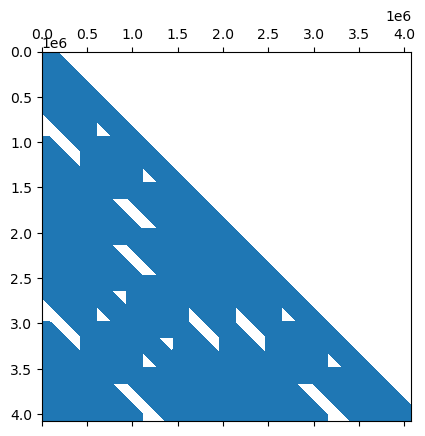

In [ ]:
plt.spy(cov)

In [ ]:
plt.spy(sigma)

NameError: name 'sigma' is not defined

POWER USED FOR CHOL: 10^-17


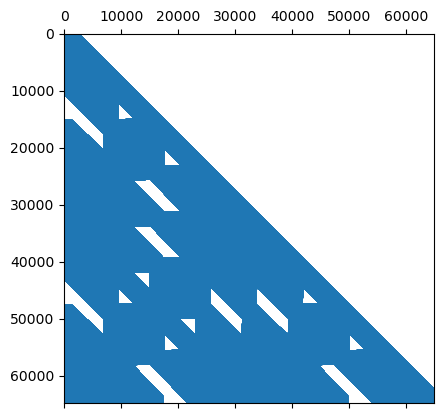

In [ ]:
chol = input_statistics_manager_2d._get_chol(sigma)
plt.spy(chol)